# Unified Binary Classification Pipeline

This notebook consolidates the different approaches (standard ML, interpretable models, competitor benchmark) into a single pipeline with:
- 90/10 stratified train/test split
- GridSearchCV with cross-validation
- Confusion matrices and scoring
- Threshold tuning (PR-optimal and Youden's J)
- Best model & config summary per approach and per model type

## 1. Setup & Imports

In [2]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

# Project imports
from src.models import (
    SKLEARN_MODELS_SEARCH_SPACE,
    INTERPRETABLE_MODELS_SEARCH_SPACE,
    RANDOM_STATE,
)
from src.utils import *
from src.competitors import *

## 2. Load & Preprocess Data

In [4]:
_, df = load_metabric_data()

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


In [5]:
X_train, X_test,\
      y_train, y_test,\
      preprocessor = prepare_data_splits_per_model(approach="with_augmentation", df=df)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


Applying one-hot encoding to categorical columns: 
cancer_type_detailed               5 levels
er_status_measured_by_ihc          2 levels
her2_status_measured_by_snp6       4 levels
tumor_other_histologic_subtype     6 levels
inferred_menopausal_state          2 levels
integrative_cluster               11 levels
primary_tumor_laterality           2 levels
oncotree_code                      5 levels
3-gene_classifier_subtype          3 levels
dtype: str

---------


New columns after one-hot encoding:
3-gene_classifier_subtype_ER+/HER2- Low Prolif
3-gene_classifier_subtype_HER2+
cancer_type_detailed_Breast Invasive Ductal Carcinoma
cancer_type_detailed_Breast Invasive Lobular Carcinoma
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma
er_status_measured_by_ihc_Positve
her2_status_measured_by_snp6_LOSS
her2_status_measured_by_snp6_NEUTRAL
her2_status_measured_by_snp6_UNDEF
inferred_menopausal_state_Pre
integrati

/Users/lemnos/Documents/gits/DAMA_Hackathon/src/utils.py:169: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


((611, 705), (68, 705), (611,), (68,))

In [9]:
type(preprocessor(X_train))

Missing columns report:
 cellularity                    7
neoplasm_histologic_grade     28
mutation_count                 7
tumor_size                     1
tumor_stage                  143
dtype: int64


sklearn.pipeline.Pipeline

In [11]:
preprocess_module = preprocessor(X_train)
X_train_transformed = preprocess_module.fit_transform(X_train)  
X_test_transformed = preprocess_module.transform(X_test)       

Missing columns report:
 cellularity                    7
neoplasm_histologic_grade     28
mutation_count                 7
tumor_size                     1
tumor_stage                  143
dtype: int64


In [15]:
X_train_transformed['discordant_molecular_score'].mean(), X_test_transformed['discordant_molecular_score'].mean()

(np.float64(-1.7443766017023736e-17), np.float64(0.09994878186469443))

## 3. Train / Test Split (90/10)

## 4. Define Scoring & Helper Functions

In [16]:
SCORING = {
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy',
}
REFIT_METRIC = 'roc_auc'  # TODO: change if you prefer another refit metric
CV_FOLDS = 5              # TODO: adjust number of CV folds if needed

In [17]:
def make_full_pipeline(preprocessor, classifier):
    """Combine the preprocessing pipeline with a classifier step."""
    return Pipeline([
        *preprocessor.steps,
        ('classifier', classifier),
    ])


def evaluate_at_threshold(y_true, proba, threshold):
    """Return predictions and key metrics at a given threshold."""
    preds = (proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'f1': f1_score(y_true, preds),
        'balanced_acc': balanced_accuracy_score(y_true, preds),
        'roc_auc': roc_auc_score(y_true, preds),
        'predictions': preds,
    }


def find_best_threshold_pr(y_true, proba):
    """Find threshold maximizing F1 on the precision-recall curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = int(np.argmax(f1_scores))
    return thresholds[min(best_idx, len(thresholds) - 1)]


def find_best_threshold_youden(y_true, proba):
    """Find threshold maximizing Youden's J statistic on the ROC curve."""
    fpr, tpr, thresholds = roc_curve(y_true, proba)
    j_scores = tpr - fpr
    return thresholds[int(np.argmax(j_scores))]


def plot_confusion_matrix(y_true, preds, title=''):
    """Display confusion matrix."""
    ConfusionMatrixDisplay.from_predictions(y_true, preds, cmap='Blues')
    plt.title(title)
    plt.show()

## 5. Run All Approaches

We loop over three *approach* groups:
1. **Standard ML** (`MODELS_WITH_SEARCH_SPACE`) — Logistic Regression, Random Forest, SVM
2. **Interpretable** (`INTERPRETABLE_MODELS_WITH_SEARCH_SPACE`) — EBM, FIGS, RuleFit, …
3. **Competitor Benchmark** (Rezaeian gene signature) — *optional, add your own models/params*

In [18]:
# Collect all approaches into one registry.
# Each entry: (approach_name, model_registry_dict)
# The model_registry_dict maps model_name -> (estimator, param_grid)
# Note: param_grid keys are already prefixed with 'classifier__'

APPROACHES = {
    'Standard ML': SKLEARN_MODELS_SEARCH_SPACE,
    'Interpretable': INTERPRETABLE_MODELS_SEARCH_SPACE,
}

In [21]:
results = []  # will hold one dict per (approach, model)


for approach_name, model_registry in APPROACHES.items():
    print(f"\n{'='*60}")
    print(f"  Approach: {approach_name}")
    print(f"{'='*60}")

    for model_name, (estimator, param_grid) in model_registry.items():
        print(f"\n--- {model_name} ---")

        pipe = make_full_pipeline(preprocess_module, estimator)

        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=CV_FOLDS,
            scoring=SCORING,
            refit=REFIT_METRIC,
            n_jobs=-1,
            error_score='raise',  # TODO: set to np.nan to skip failing configs
        )

        try:
            grid.fit(X_train, y_train)
        except Exception as e:
            print(f"  [SKIP] {model_name} failed: {e}")
            continue

        proba = grid.predict_proba(X_test)[:, 1]

        # CV scores
        cv_auc = grid.best_score_
        cv_bal_acc = grid.cv_results_['mean_test_balanced_accuracy'][grid.best_index_]

        # Test scores at default threshold
        y_pred_default = grid.predict(X_test)
        test_auc = roc_auc_score(y_test, proba)
        test_bal_acc = balanced_accuracy_score(y_test, y_pred_default)
        test_f1 = f1_score(y_test, y_pred_default)

        print(
            f"  CV AUC={cv_auc:.3f}  CV BalAcc={cv_bal_acc:.3f} | "
            f"Test AUC={test_auc:.3f}  Test BalAcc={test_bal_acc:.3f}  Test F1={test_f1:.3f}"
        )

        results.append({
            'approach': approach_name,
            'model': model_name,
            'best_params': grid.best_params_,
            'cv_auc': cv_auc,
            'cv_bal_acc': cv_bal_acc,
            'test_auc': test_auc,
            'test_bal_acc': test_bal_acc,
            'test_f1': test_f1,
            'proba': proba,
            'grid': grid,
        })


  Approach: Standard ML

--- Logistic Regression ---


/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/py

  CV AUC=0.666  CV BalAcc=0.544 | Test AUC=0.611  Test BalAcc=0.557  Test F1=0.222

--- Random Forest ---
  CV AUC=0.686  CV BalAcc=0.504 | Test AUC=0.718  Test BalAcc=0.500  Test F1=0.000

--- SVM ---
  CV AUC=0.678  CV BalAcc=0.500 | Test AUC=0.623  Test BalAcc=0.500  Test F1=0.000

  Approach: Interpretable

--- FIGS ---
  CV AUC=0.605  CV BalAcc=0.555 | Test AUC=0.607  Test BalAcc=0.562  Test F1=0.273

--- RuleFit ---


/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/linear_model/_logistic

  CV AUC=0.670  CV BalAcc=0.509 | Test AUC=0.757  Test BalAcc=0.500  Test F1=0.000

--- SkopeRules ---
  [SKIP] SkopeRules failed: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

--- BoostedRules ---


/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  

  CV AUC=0.679  CV BalAcc=0.507 | Test AUC=0.689  Test BalAcc=0.500  Test F1=0.000

--- GreedyTree ---


/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.w

  CV AUC=0.615  CV BalAcc=0.544 | Test AUC=0.640  Test BalAcc=0.486  Test F1=0.095

--- TreeGAM ---
  [SKIP] TreeGAM failed: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.


## 6. Confusion Matrices (Default Threshold = 0.5)

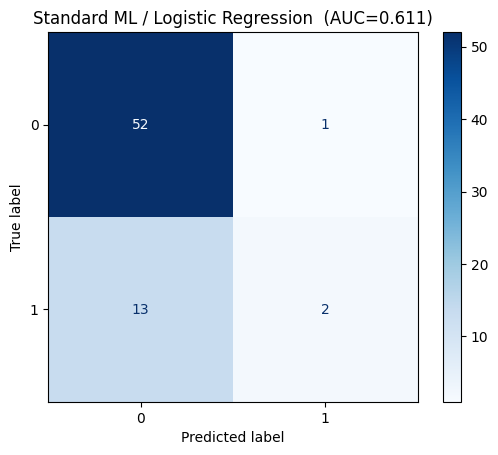

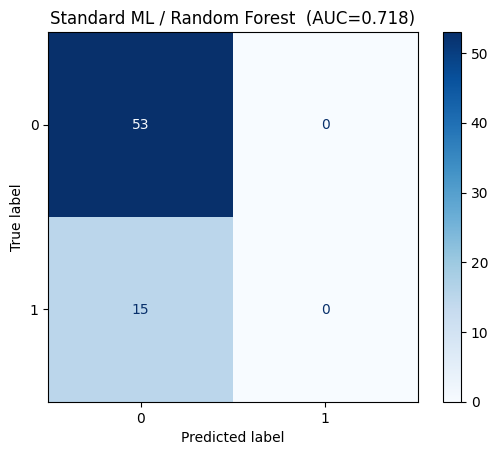

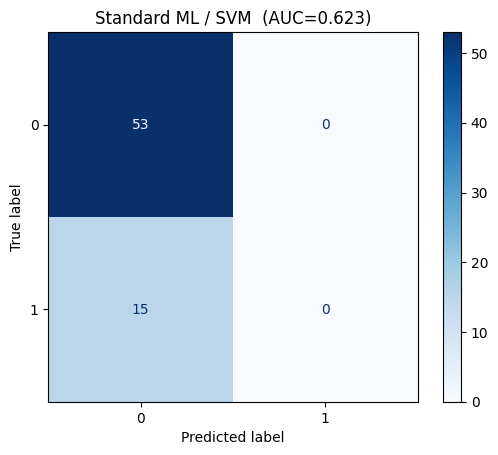

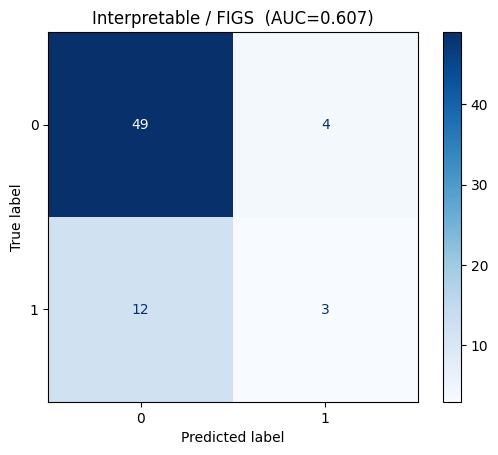

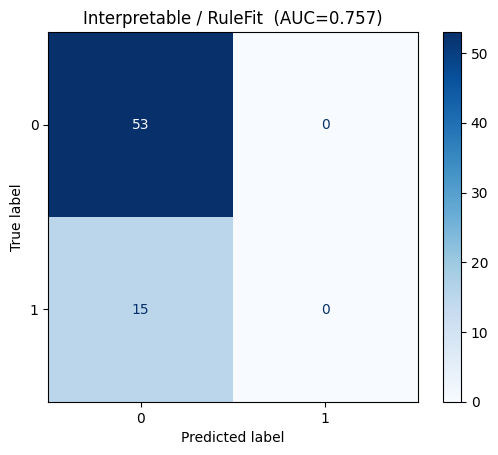

/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but BoostedRulesClassifier was fitted without feature names
  warnings.warn(


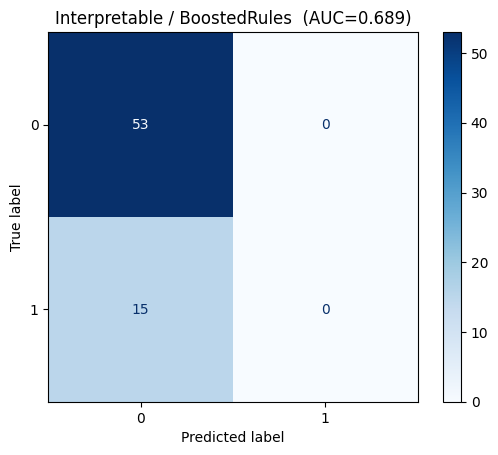

/opt/anaconda3/envs/metabric/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but GreedyTreeClassifier was fitted without feature names
  warnings.warn(


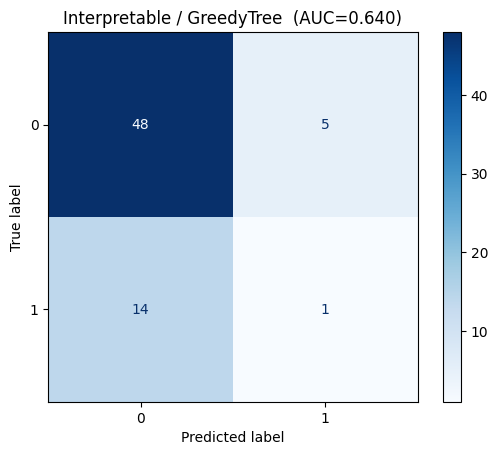

In [22]:
for r in results:
    preds = r['grid'].predict(X_test)
    title = f"{r['approach']} / {r['model']}  (AUC={r['test_auc']:.3f})"
    plot_confusion_matrix(y_test, preds, title=title)

## 7. Threshold Tuning

For each trained model we compute:
- **PR-optimal** threshold (maximizes F1)
- **Youden's J** threshold (maximizes TPR − FPR)

In [23]:
tuned_rows = []

for r in results:
    proba = r['proba']

    # PR-optimal threshold
    thr_pr = find_best_threshold_pr(y_test, proba)
    eval_pr = evaluate_at_threshold(y_test, proba, thr_pr)

    # Youden's J threshold
    thr_j = find_best_threshold_youden(y_test, proba)
    eval_j = evaluate_at_threshold(y_test, proba, thr_j)

    tuned_rows.append({
        'approach': r['approach'],
        'model': r['model'],
        'default_f1': r['test_f1'],
        'pr_threshold': thr_pr,
        'pr_f1': eval_pr['f1'],
        'pr_bal_acc': eval_pr['balanced_acc'],
        'youden_threshold': thr_j,
        'youden_f1': eval_j['f1'],
        'youden_bal_acc': eval_j['balanced_acc'],
    })

df_tuned = pd.DataFrame(tuned_rows)
df_tuned

,approach,model,default_f1,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
0,Standard ML,Logistic Regression,0.222222,0.216075,0.444444,0.644025,0.216075,0.444444,0.644025
1,Standard ML,Random Forest,0.000000,0.296704,0.526316,0.710692,0.296704,0.526316,0.710692
2,Standard ML,SVM,0.000000,0.229112,0.421053,0.625157,0.229112,0.421053,0.625157
3,Interpretable,FIGS,0.272727,0.304688,0.393443,0.579245,0.389510,0.363636,0.586792
4,Interpretable,RuleFit,0.000000,0.016359,0.560000,0.768553,0.016359,0.560000,0.768553
5,Interpretable,BoostedRules,0.000000,0.178719,0.478261,0.677987,0.178719,0.478261,0.677987
6,Interpretable,GreedyTree,0.095238,0.118421,0.444444,0.645283,0.118421,0.444444,0.645283


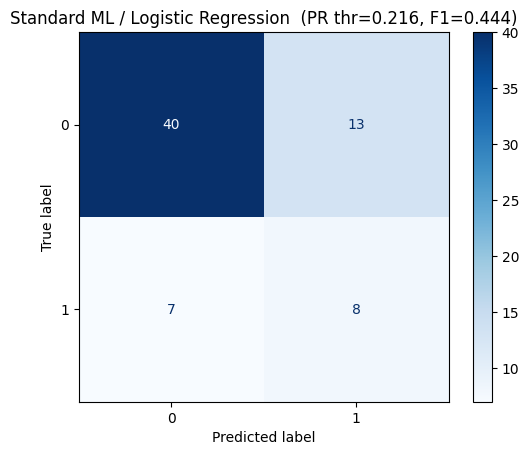

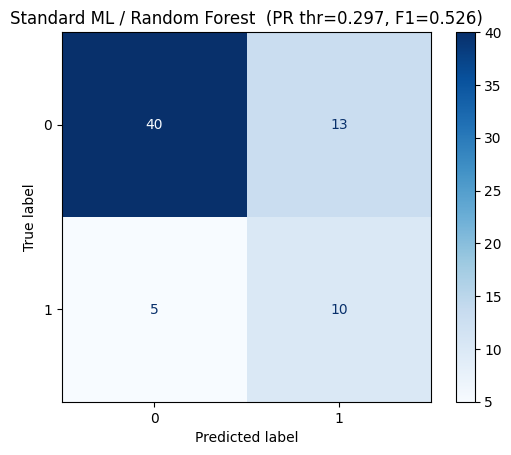

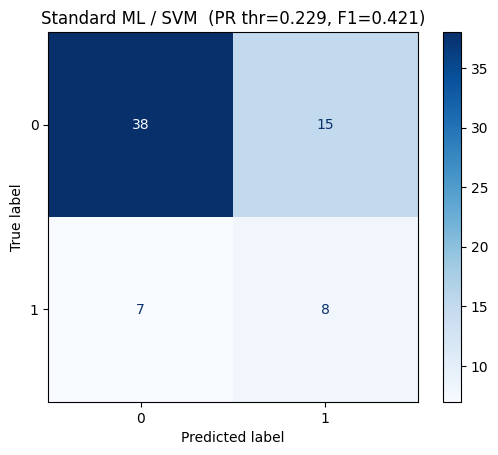

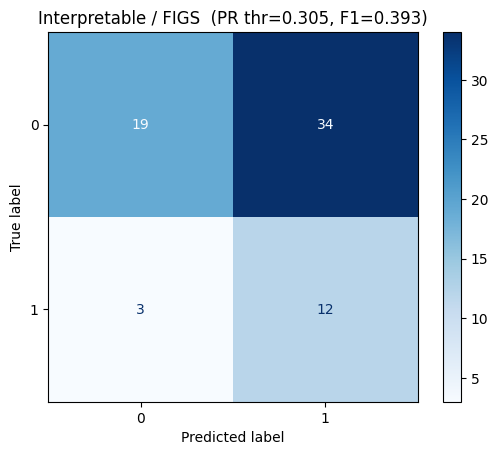

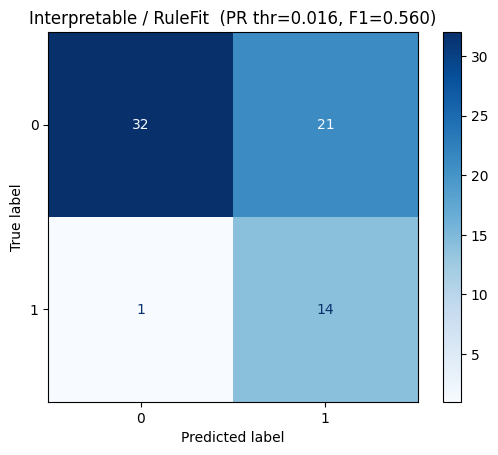

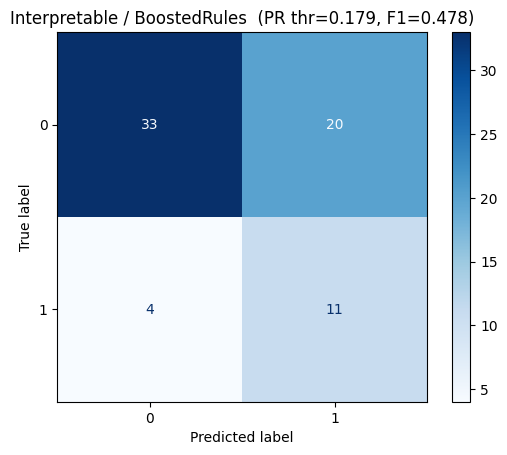

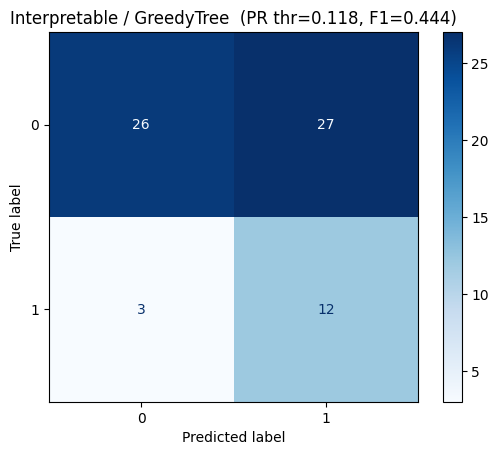

In [24]:
# Confusion matrices with the PR-tuned threshold
for r, row in zip(results, tuned_rows):
    preds = (r['proba'] >= row['pr_threshold']).astype(int)
    title = (
        f"{r['approach']} / {r['model']}  "
        f"(PR thr={row['pr_threshold']:.3f}, F1={row['pr_f1']:.3f})"
    )
    plot_confusion_matrix(y_test, preds, title=title)

## 8. Summary: Best Model per Approach

In [25]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('proba', 'grid')}
    for r in results
])

# Best model per approach (by test AUC)
best_per_approach = df_results.loc[
    df_results.groupby('approach')['test_auc'].idxmax()
]
print("Best model per approach (by Test AUC):")
best_per_approach[['approach', 'model', 'test_auc', 'test_f1', 'test_bal_acc', 'best_params']]

Best model per approach (by Test AUC):


,approach,model,test_auc,test_f1,test_bal_acc,best_params
4,Interpretable,RuleFit,0.757233,0.0,0.5,"{'classifier__max_rules': 30, 'classifier__n_e..."
1,Standard ML,Random Forest,0.718239,0.0,0.5,"{'classifier__class_weight': 'balanced', 'clas..."


## 9. Summary: Best Config per Model Type (RF, LogReg)

In [26]:
# Filter for RF and Logistic Regression across all approaches
TARGET_MODELS = ['Random Forest', 'Logistic Regression']

df_target = df_results[df_results['model'].isin(TARGET_MODELS)]

if df_target.empty:
    print("No RF / LogReg entries found. Check model names in APPROACHES.")
else:
    best_per_model = df_target.loc[
        df_target.groupby('model')['test_auc'].idxmax()
    ]
    print("Best config per model type (by Test AUC):")
    best_per_model[['approach', 'model', 'test_auc', 'test_f1', 'test_bal_acc', 'best_params']]

Best config per model type (by Test AUC):


## 10. Full Leaderboard

In [27]:
df_results.sort_values('test_auc', ascending=False)[
    ['approach', 'model', 'cv_auc', 'cv_bal_acc', 'test_auc', 'test_f1', 'test_bal_acc']
]

,approach,model,cv_auc,cv_bal_acc,test_auc,test_f1,test_bal_acc
4,Interpretable,RuleFit,0.669747,0.508814,0.757233,0.000000,0.500000
1,Standard ML,Random Forest,0.686194,0.504425,0.718239,0.000000,0.500000
5,Interpretable,BoostedRules,0.679219,0.507229,0.689308,0.000000,0.500000
6,Interpretable,GreedyTree,0.614965,0.544177,0.639623,0.095238,0.486164
2,Standard ML,SVM,0.677695,0.500000,0.622642,0.000000,0.500000
0,Standard ML,Logistic Regression,0.665880,0.543519,0.611321,0.222222,0.557233
3,Interpretable,FIGS,0.604879,0.554630,0.606918,0.272727,0.562264


---

### TODOs / Placeholders

- **Add Competitor Approach**: import `get_rezaeian_features` / `map_competitor_features` and wire a separate feature subset through the same loop.  
- **Add / Remove Metrics**: extend `SCORING` dict and `evaluate_at_threshold` as needed.  
- **Adjust Param Grids**: the grids come from `src/models.py` — edit there or override inline.  
- **Change Refit Metric**: set `REFIT_METRIC` to e.g. `'balanced_accuracy'`.  
- **Preprocessor**: `build_preprocessor()` uses `SmartClinicalImputer` + `DiscordantSignatureAdder` + `SimpleImputer` + `StandardScaler`. Swap or extend in `src/utils.py`.  
- **Add plots**: ROC curves, calibration curves, SHAP, etc.